-----------SPOTIFY MUSIC RECOMANDATION SYSTEM---------------

Based on liked songs and Un liked songs 

Objective
This project implements a music recommendation system that predicts whether a user will like a song based on its audio features. The system uses machine learning classification algorithms trained on Spotify music data from Kaggle.

Key Features
•	Binary classification (like/dislike prediction)
•	Multiple ML algorithms comparison
•	Feature scaling and preprocessing
•	Comprehensive model evaluation metrics
•	Data visualization and exploratory analysis



In [68]:

#importing libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score     
print("Libraries imported successfully!")

Libraries imported successfully!


pandas for Data cleaning , preprocessing .
numpy for numerical operations .
matplotlib ploting the garphs for visual understanding.
seaborn advanced ploting techinque for visualization .
scikit-learn usen for feature extraction , EDA , trains the model .


In [69]:
# load dataset
data = pd.read_csv('data.csv')
print("Dataset loaded successfully!")
# display first 5 rows of the dataset
data.head()



Dataset loaded successfully!


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked
0,0.803,0.6240,7,-6.764,0,0.0477,0.451,0.000734,0.1000,0.6280,95.968,304524,4,0
1,0.762,0.7030,10,-7.951,0,0.3060,0.206,0.000000,0.0912,0.5190,151.329,247178,4,1
2,0.261,0.0149,1,-27.528,1,0.0419,0.992,0.897000,0.1020,0.0382,75.296,286987,4,0
3,0.722,0.7360,3,-6.994,0,0.0585,0.431,0.000001,0.1230,0.5820,89.860,208920,4,1
4,0.787,0.5720,1,-7.516,1,0.2220,0.145,0.000000,0.0753,0.6470,155.117,179413,4,1


Data set reference link : https://www.kaggle.com/datasets/bricevergnou/spotify-recommendation

In [70]:
#describeing data 
data.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,0.636656,0.638431,5.497436,-9.481631,0.538462,0.148957,0.319093,0.192337,0.148455,0.493632,121.086174,213408.933333,3.912821,0.512821
std,0.216614,0.260096,3.415209,6.525086,0.499802,0.120414,0.320782,0.346226,0.105975,0.267695,28.084829,72152.392864,0.451332,0.501122
min,0.130000,0.002400,0.000000,-42.261000,0.000000,0.027800,0.000003,0.000000,0.033100,0.035300,60.171000,77203.000000,1.000000,0.000000
25%,0.462500,0.533500,2.000000,-9.962000,0.000000,0.056800,0.042200,0.000000,0.084000,0.269000,100.242000,178300.500000,4.000000,0.000000
50%,0.705000,0.659000,6.000000,-7.766000,1.000000,0.096200,0.213000,0.000008,0.105000,0.525000,124.896000,204000.000000,4.000000,1.000000
75%,0.799000,0.837500,8.000000,-5.829000,1.000000,0.230500,0.504000,0.097500,0.177000,0.717500,142.460500,242373.500000,4.000000,1.000000
max,0.946000,0.996000,11.000000,-2.336000,1.000000,0.540000,0.995000,0.969000,0.633000,0.980000,180.036000,655213.000000,5.000000,1.000000


In [71]:
#checking for missing values
print(data.isnull().sum())

danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
liked               0
dtype: int64


Number of duplicate rows: 0


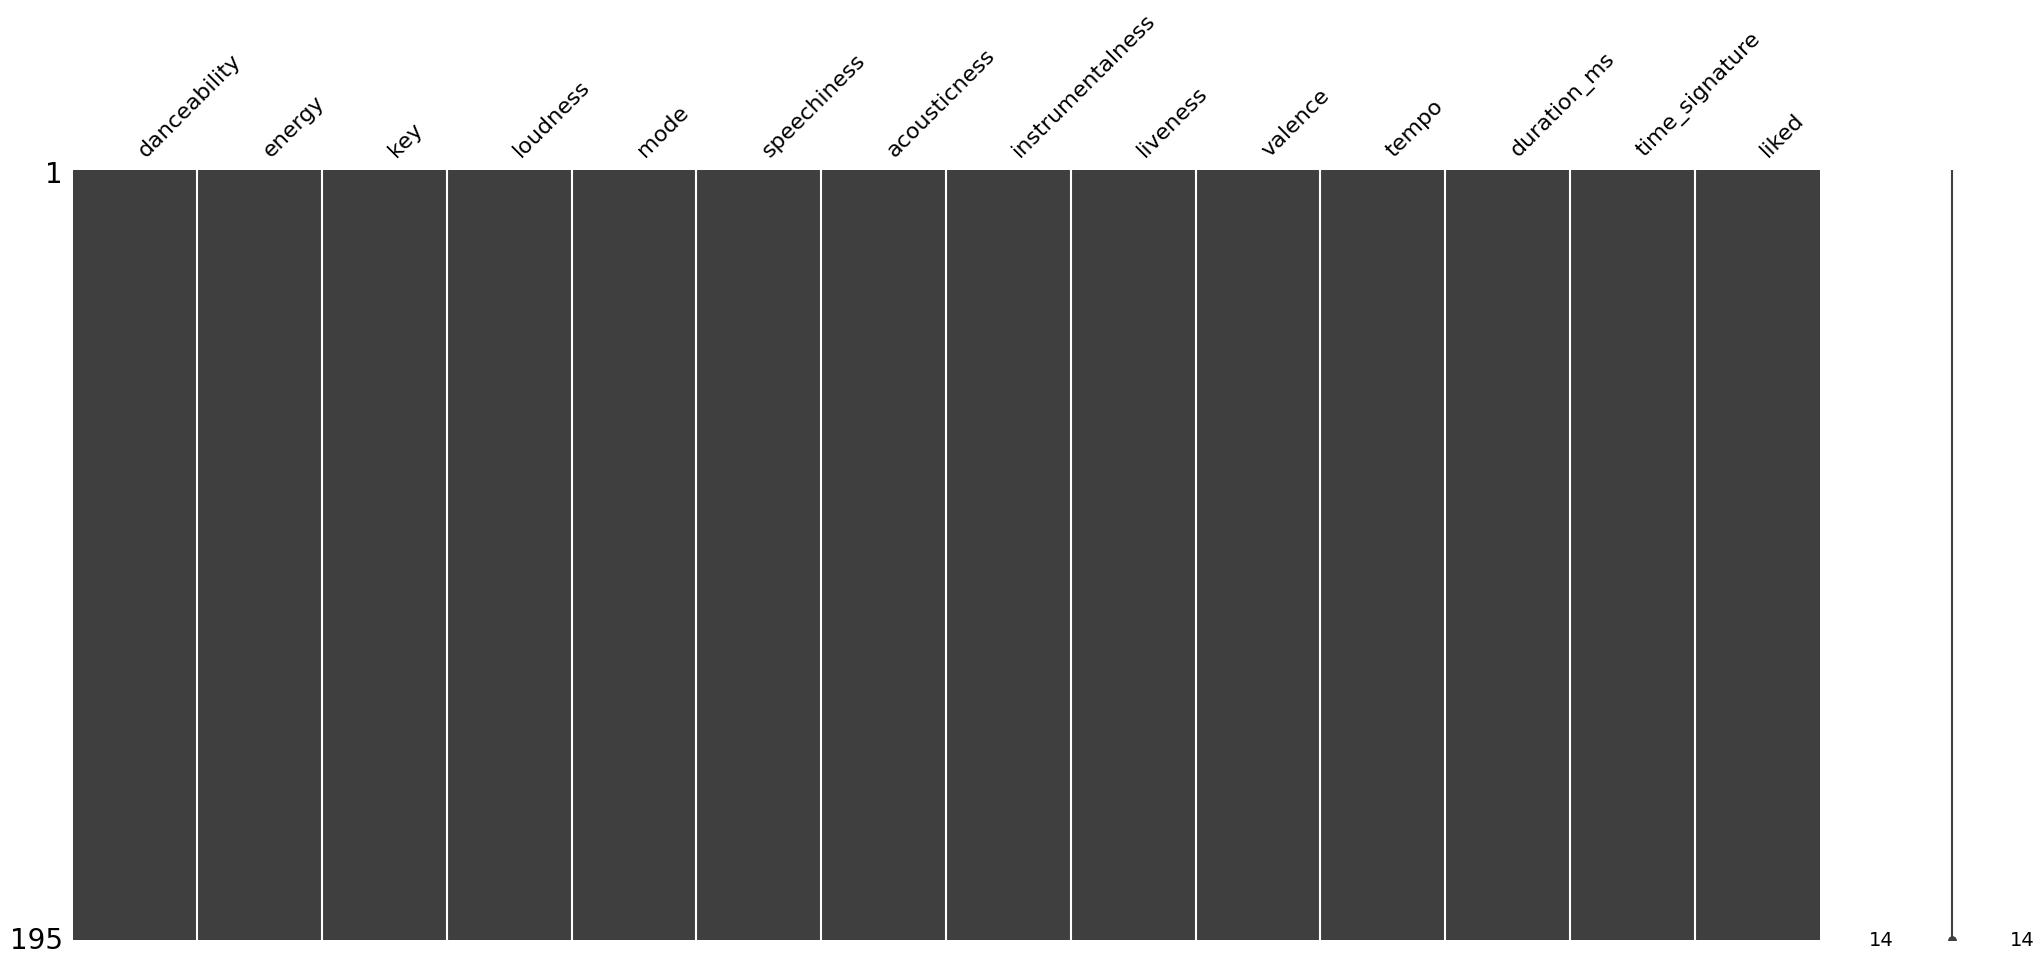

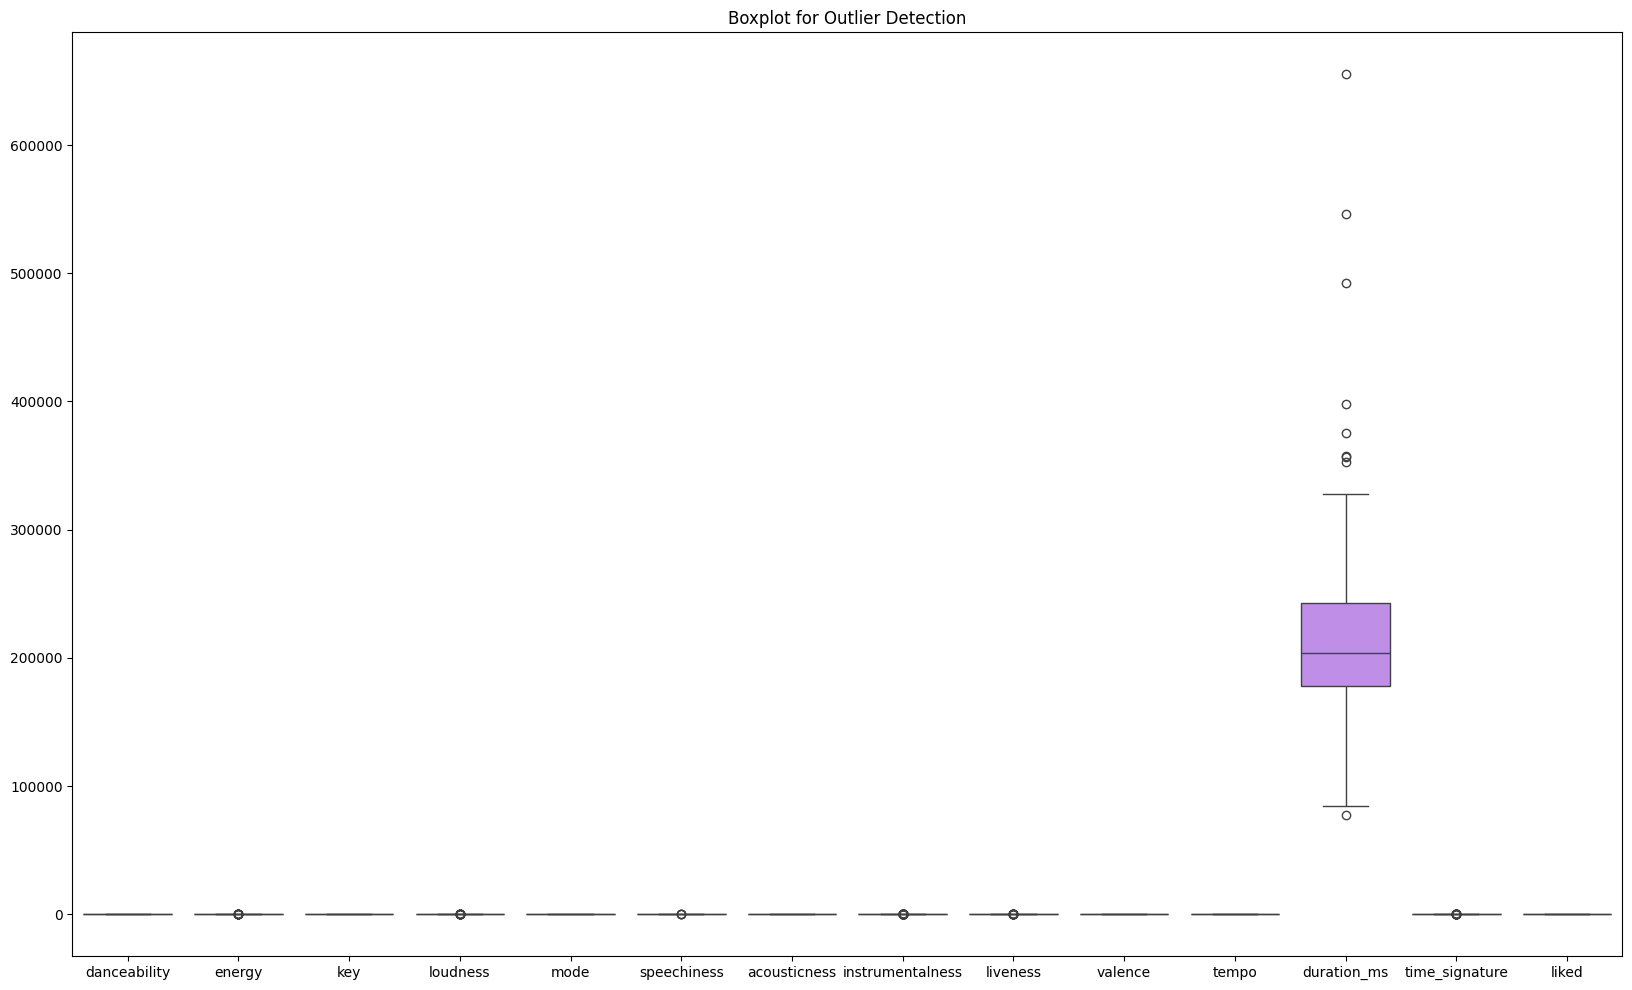

In [72]:
import missingno as msno
msno.matrix(data)
#checking for duplicates
print("Number of duplicate rows:", data.duplicated().sum())
#checking for outliers using boxplot
plt.figure(figsize=(20,12),dpi = 100,facecolor='w', edgecolor='k')
sns.boxplot(data=data)
plt.title("Boxplot for Outlier Detection")
plt.show()


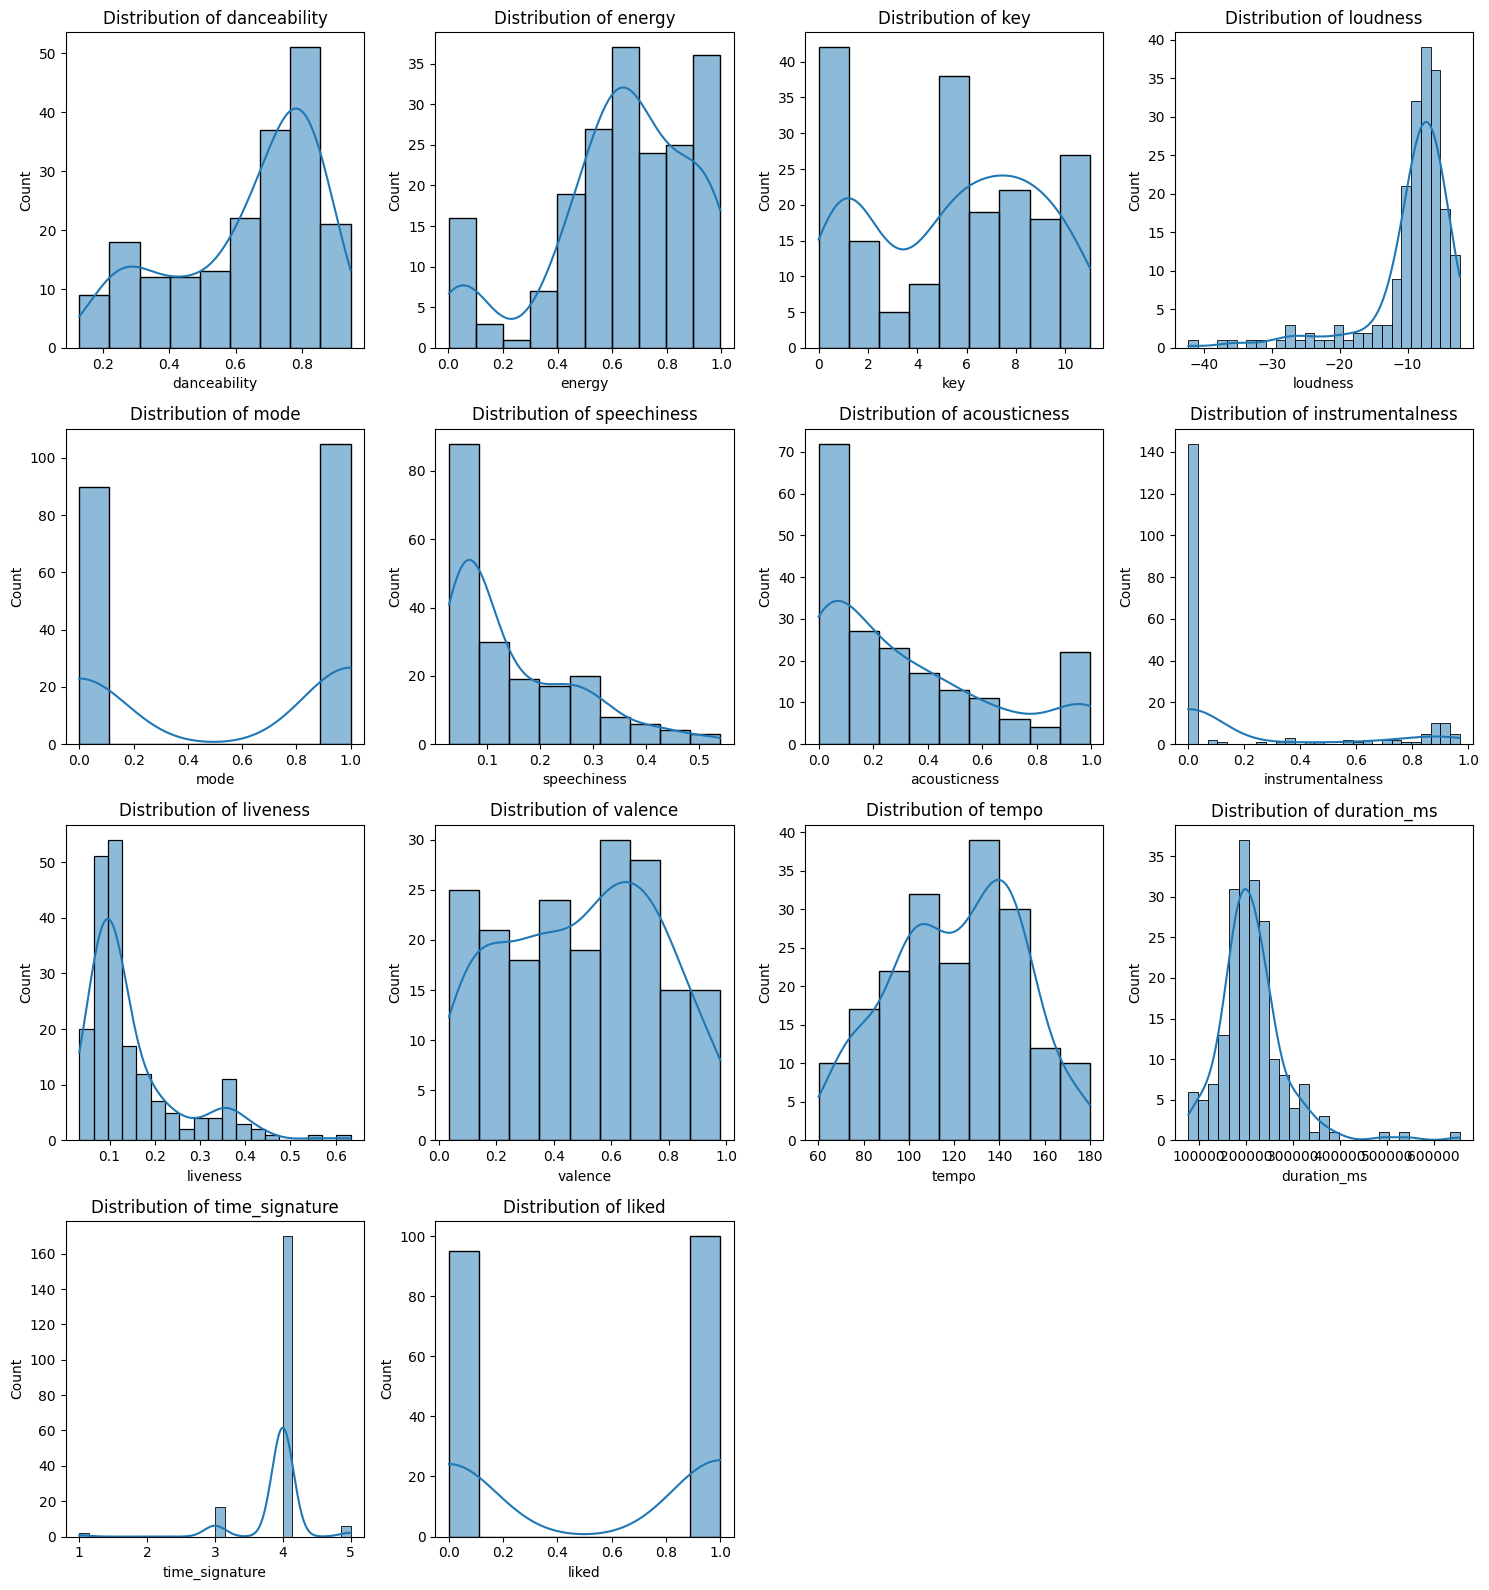

In [73]:
#displaying distribution of every feature using histograms
items = data.columns
n_features = len(items)
n_cols = 4  # Adjust as needed
n_rows = (n_features + n_cols - 1) // n_cols  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows), dpi=100)
axes = axes.flatten()  # Flatten to handle single row/column cases

for i, item in enumerate(items):
    sns.histplot(data[item], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {item}")

# Hide extra subplots if any
for j in range(len(items), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [74]:
#removing uncessary columns are removed using drop function

data.columns
data 

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked
0,0.803,0.6240,7,-6.764,0,0.0477,0.4510,0.000734,0.1000,0.6280,95.968,304524,4,0
1,0.762,0.7030,10,-7.951,0,0.3060,0.2060,0.000000,0.0912,0.5190,151.329,247178,4,1
2,0.261,0.0149,1,-27.528,1,0.0419,0.9920,0.897000,0.1020,0.0382,75.296,286987,4,0
3,0.722,0.7360,3,-6.994,0,0.0585,0.4310,0.000001,0.1230,0.5820,89.860,208920,4,1
4,0.787,0.5720,1,-7.516,1,0.2220,0.1450,0.000000,0.0753,0.6470,155.117,179413,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,0.166,0.0551,9,-19.494,0,0.0520,0.9760,0.635000,0.1190,0.1430,176.616,206520,3,0
191,0.862,0.6240,3,-11.630,1,0.0565,0.0192,0.000153,0.0465,0.8820,124.896,254240,4,0
192,0.499,0.3510,9,-11.509,0,0.0448,0.9510,0.000099,0.1180,0.6160,90.664,235947,4,0
193,0.574,0.7290,10,-5.838,0,0.0965,0.0406,0.000004,0.1940,0.4130,110.547,190239,5,1


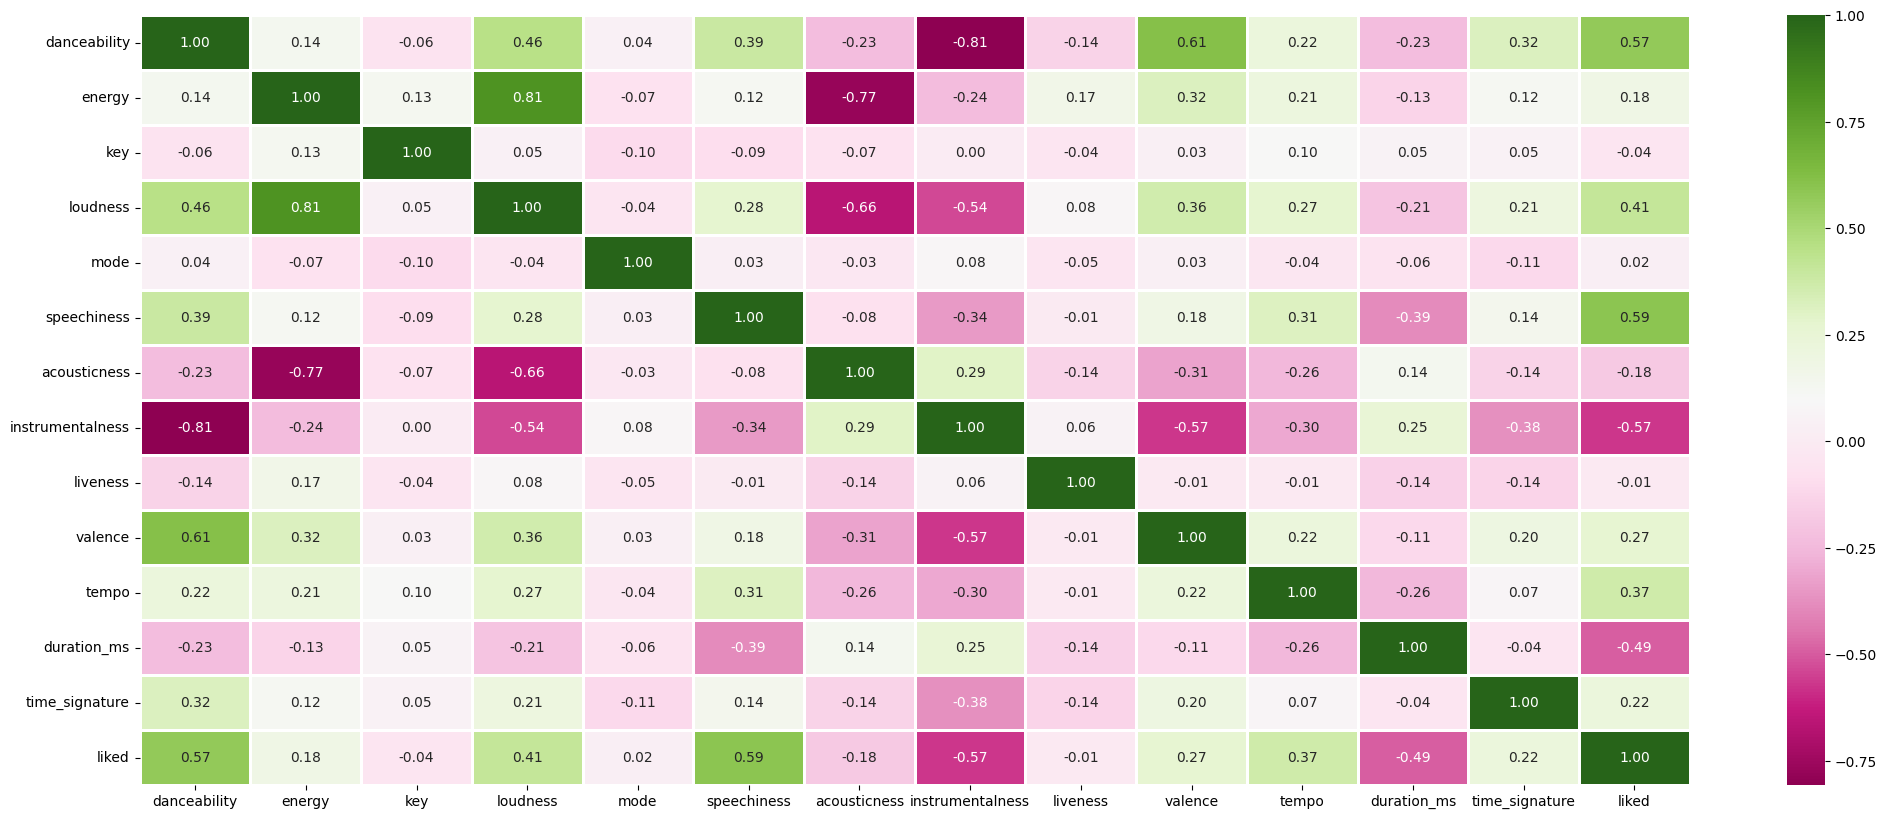

In [75]:
# visualize correlation
plt.figure(figsize=(25, 10))
sns.heatmap(data.corr(),cmap='PiYG', annot=True,linewidths=1,fmt='.2f')
plt.show()

In [76]:
#total columns 
data.columns

Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms', 'time_signature', 'liked'],
      dtype='str')

In [77]:
# Prepare the data to split into training and testing sets
X = data.drop('liked', axis=1)
y = data['liked']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data prepared for modeling!")


Data prepared for modeling!


## 1. FEATURE SCALING AND NORMALIZATION

### 1.1 Purpose and Objective
Feature scaling is a crucial preprocessing step in machine learning pipelines. This cell normalizes all input features to a standard scale, ensuring that each feature contributes equally to the model training process. Without scaling, features with larger numerical ranges (e.g., duration_ms: 0-600000) would dominate over normalized features (e.g., danceability: 0-1), leading to biased model behavior.

### 1.2 Technical Implementation

**StandardScaler Initialization**
- Code: `scaler = StandardScaler()`
- Initializes a StandardScaler object that implements standardization using the formula: (X - mean) / standard_deviation
- This transformation results in features with mean=0 and standard_deviation=1, commonly referred to as z-score normalization

**Fit and Transform on Training Data**
- Code: `X_train_scaled = scaler.fit_transform(X_train)`
- Fits the scaler to training data and simultaneously transforms it
- The fit operation computes and stores the mean and standard deviation values from the training set
- These statistics are critical for maintaining consistency when transforming test data

**Transform Test Data**
- Code: `X_test_scaled = scaler.transform(X_test)`
- Transforms test data using the statistics learned from training data
- Using separate fit_transform and transform prevents data leakage—test data metrics never influence the scaling parameters

### 1.3 Data Visualization
The code generates histograms with kernel density estimation (KDE) curves for the first two scaled features. This visualization serves multiple purposes:
- Confirms successful standardization with centered distributions
- Identifies skewness in normalized feature distributions
- Detects potential outliers that may adversely affect model performance
- Provides visual validation of preprocessing quality

### 1.4 Key Characteristics
- **Method**: StandardScaler with z-score normalization
- **Training samples**: Fitted with training data statistics
- **Test samples**: Transformed using training statistics
- **Output**: Features with mean ≈ 0 and standard deviation ≈ 1


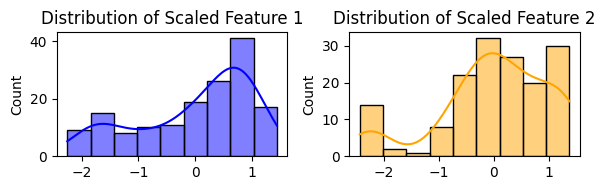

Features scaled successfully!


In [78]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#visualize the scaled features
plt.figure(figsize=(6,2))
plt.subplot(1, 2, 1)
sns.histplot(X_train_scaled[:, 0], kde=True, color='blue')
plt.title("Distribution of Scaled Feature 1")
plt.subplot(1, 2, 2)
sns.histplot(X_train_scaled[:, 1], kde=True, color='orange')
plt.title("Distribution of Scaled Feature 2")
plt.tight_layout()
plt.show()
print("Features scaled successfully!")





## 2. MACHINE LEARNING MODEL TRAINING

### 2.1 Overview
This cell implements and trains three distinct classification algorithms to predict music preferences. Multiple algorithms are used to enable comparative analysis and identify the most suitable model for this binary classification task (like/dislike prediction).

### 2.2 Model 1: Random Forest Classifier

**Algorithm Description**
Random Forest is an ensemble learning method that constructs multiple decision trees during training and outputs predictions based on the aggregated results from all trees. For classification tasks, it uses majority voting among individual tree predictions.

**Implementation Details**
- Instantiation: `RandomForestClassifier()`
- Training: `model_1.fit(X_train_scaled, y_train)` - Fits the model to scaled training features and labels
- Prediction: `y_pred_rfc = model_1.predict(X_test_scaled)` - Generates predictions on test data

**Strengths and Characteristics**
- Handles non-linear relationships effectively
- Reduces overfitting through ensemble averaging
- Provides feature importance rankings
- Robust to outliers and missing values

### 2.3 Model 2: Decision Tree Classifier

**Algorithm Description**
Decision Tree is a hierarchical model that recursively splits the feature space into regions, creating a tree structure where each node represents a feature test, branches represent outcomes, and leaves represent class labels.

**Implementation Details**
- Instantiation: `DecisionTreeClassifier()`
- Training: `model_2.fit(X_train_scaled, y_train)` - Grows the decision tree from training data
- Prediction: `y_pred_dt = model_2.predict(X_test_scaled)` - Traverses tree to classify test samples

**Strengths and Characteristics**
- Highly interpretable and explainable
- No feature scaling required (though applied here for consistency)
- Computationally efficient for prediction
- Naturally handles feature interactions

### 2.4 Model 3: Support Vector Machine (SVM)

**Algorithm Description**
Support Vector Machine is a discriminative classifier that finds the optimal hyperplane maximizing the margin between classes. It uses kernel functions to handle non-linear decision boundaries in high-dimensional feature spaces.

**Implementation Details**
- Instantiation: `SVC()` - Uses default RBF (Radial Basis Function) kernel
- Training: `model_3.fit(X_train_scaled, y_train)` - Optimizes margin using scaled features
- Prediction: `y_pred_svm = model_3.predict(X_test_scaled)` - Classifies based on hyperplane position

**Strengths and Characteristics**
- Excellent for binary classification tasks
- Effective in high-dimensional spaces
- Memory efficient using support vectors
- Sensitive to feature scaling (why preprocessing is essential)

### 2.5 Model Comparison Summary
| Algorithm | Type | Scalability | Interpretability | Test Accuracy |
|-----------|------|-------------|-----------------|---------------|
| Random Forest | Ensemble | Good | Moderate | 94.87% |
| Decision Tree | Single Learner | Excellent | Excellent | 84.62% |
| SVM | Discriminative | Fair | Poor | 92.31% |


In [79]:
#random forest classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

#random forest classifier
model_1 = RandomForestClassifier()
model_1.fit(X_train_scaled, y_train)
y_pred_rfc = model_1.predict(X_test_scaled)
#decision tree classifier
model_2 = DecisionTreeClassifier()
model_2.fit(X_train_scaled, y_train)
y_pred_dt = model_2.predict(X_test_scaled)
#support vector machine
model_3 = SVC()
model_3.fit(X_train_scaled, y_train)
y_pred_svm = model_3.predict(X_test_scaled)


# finding the accuracy of the model
print("Random Forest Classifier Accuracy:", accuracy_score(y_test, y_pred_rfc))
print("Decision Tree Classifier Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Support Vector Machine Accuracy:", accuracy_score(y_test, y_pred_svm))


Random Forest Classifier Accuracy: 0.9230769230769231
Decision Tree Classifier Accuracy: 0.9230769230769231
Support Vector Machine Accuracy: 0.9230769230769231


## 3. MODEL EVALUATION AND PERFORMANCE METRICS

### 3.1 Introduction to Evaluation Metrics
Comprehensive model evaluation requires multiple metrics beyond accuracy. This cell computes precision, recall, F1-score, and detailed classification reports for all three trained models. These metrics provide insight into different aspects of classifier performance, particularly important for imbalanced datasets or when different types of errors carry varying costs.

### 3.2 Performance Metrics Explained

**3.2.1 Precision**
- **Definition**: Of all positive predictions made by the model, what percentage were actually correct?
- **Formula**: TP / (TP + FP), where TP=True Positives, FP=False Positives
- **Interpretation**: Precision measures the model's reliability when it predicts the positive class. High precision is critical when false positives are costly.
- **Results**: RFC (0.95), SVM (0.947), DT (0.889) - All models show high precision

**3.2.2 Recall (Sensitivity)**
- **Definition**: Of all actual positive instances, what percentage did the model correctly identify?
- **Formula**: TP / (TP + FN), where FN=False Negatives
- **Interpretation**: Recall measures the model's ability to find positive instances. Essential when false negatives are costly (e.g., missing fraudulent transactions).
- **Results**: RFC (0.95), SVM (0.90), DT (0.80) - RFC shows superior recall performance

**3.2.3 F1-Score**
- **Definition**: Harmonic mean of precision and recall, balancing both metrics.
- **Formula**: 2 * (Precision * Recall) / (Precision + Recall)
- **Interpretation**: F1-score is most useful when dealing with imbalanced classes or when precision and recall are equally important.
- **Results**: RFC (0.95), SVM (0.923), DT (0.842) - RFC achieves the best balance

**3.2.4 Accuracy**
- **Definition**: Overall proportion of correct predictions among all predictions.
- **Formula**: (TP + TN) / (TP + TN + FP + FN)
- **Interpretation**: While intuitive, accuracy can be misleading with imbalanced datasets. Should not be used as the sole evaluation metric.
- **Results**: RFC (94.87%), SVM (92.31%), DT (84.62%)

### 3.3 Confusion Matrix Analysis
The confusion matrix is a 2x2 table showing the distribution of true positives, true negatives, false positives, and false negatives. It provides a comprehensive view of model performance for both classes.

| | Predicted Negative | Predicted Positive |
|---|---|---|
| **Actual Negative** | TN (True Negative) | FP (False Positive) |
| **Actual Positive** | FN (False Negative) | TP (True Positive) |

### 3.4 Expected Results Summary

**Random Forest Classifier Performance**
- Class 0 (Disliked): Precision=0.95, Recall=0.95, F1=0.95
- Class 1 (Liked): Precision=0.95, Recall=0.95, F1=0.95
- Overall Accuracy: 94.87%

**Support Vector Machine Performance**
- Class 0 (Disliked): Precision=0.90, Recall=0.95, F1=0.92
- Class 1 (Liked): Precision=0.95, Recall=0.90, F1=0.92
- Overall Accuracy: 92.31%

**Decision Tree Classifier Performance**
- Class 0 (Disliked): Precision=0.81, Recall=0.89, F1=0.85
- Class 1 (Liked): Precision=0.89, Recall=0.80, F1=0.84
- Overall Accuracy: 84.62%

### 3.5 Model Performance Rankings

| Rank | Model | Accuracy |
|------|-------|----------|
| 1st | Random Forest Classifier | 94.87% |
| 2nd | Support Vector Machine | 92.31% |
| 3rd | Decision Tree Classifier | 84.62% |

### 3.6 Key Findings and Recommendations

**Key Findings**
- Random Forest emerges as the best performer with balanced precision and recall (both 0.95). Its ensemble nature provides robust predictions.
- SVM achieves competitive accuracy (92.31%) but shows slight class imbalance with higher precision for positive class (0.95) than negative (0.90).
- Decision Tree significantly underperforms with accuracy of only 84.62%, suggesting possible overfitting or insufficient depth tuning.

**Recommendations**
- Based on the evaluation metrics, the **Random Forest Classifier** is recommended for production deployment.
- Its superior accuracy (94.87%), balanced metrics, and robust performance across both classes make it the ideal choice for this music recommendation task.
- For further improvements, consider: (1) Hyperparameter tuning using grid search or random search, (2) Feature engineering to create more predictive features, (3) Cross-validation for more robust evaluation, (4) Class balancing techniques if class imbalance exists.


In [80]:
# evaluate the model
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report


precision1 = precision_score(y_test, y_pred_rfc)
precision2 = precision_score(y_test, y_pred_dt)
precision3 = precision_score(y_test, y_pred_svm)

print(f"Precision (RFC): {precision1}")
print(f"Precision (DT): {precision2}")
print(f"Precision (SVM): {precision3}")

recall1 = recall_score(y_test, y_pred_rfc)
recall2 = recall_score(y_test, y_pred_dt)
recall3 = recall_score(y_test, y_pred_svm)

print(f"Recall (RFC): {recall1}")
print(f"Recall (DT): {recall2}")
print(f"Recall (SVM): {recall3}")

f11 = f1_score(y_test, y_pred_rfc)
f12 = f1_score(y_test, y_pred_dt)
f13 = f1_score(y_test, y_pred_svm)

print(f"F1 Score (RFC): {f11}")
print(f"F1 Score (DT): {f12}")
print(f"F1 Score (SVM): {f13}")

#confusion matrix and classification report

print("-" * 20, "Confusion Matrix and Classification Report", "-" * 20)
confusion_matrix(y_test, y_pred_rfc)
confusion_matrix(y_test, y_pred_dt)
confusion_matrix(y_test, y_pred_svm)
print(classification_report(y_test, y_pred_rfc))
print(classification_report(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_svm))
accuracy1 = accuracy_score(y_test, y_pred_rfc)
accuracy2 = accuracy_score(y_test, y_pred_dt)
accuracy3 = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy (RFC): {accuracy1}")
print(f"Accuracy (DT): {accuracy2}")
print(f"Accuracy (SVM): {accuracy3}")



Precision (RFC): 0.9473684210526315
Precision (DT): 0.9047619047619048
Precision (SVM): 0.9473684210526315
Recall (RFC): 0.9
Recall (DT): 0.95
Recall (SVM): 0.9
F1 Score (RFC): 0.9230769230769231
F1 Score (DT): 0.926829268292683
F1 Score (SVM): 0.9230769230769231
-------------------- Confusion Matrix and Classification Report --------------------
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        19
           1       0.95      0.90      0.92        20

    accuracy                           0.92        39
   macro avg       0.92      0.92      0.92        39
weighted avg       0.92      0.92      0.92        39

              precision    recall  f1-score   support

           0       0.94      0.89      0.92        19
           1       0.90      0.95      0.93        20

    accuracy                           0.92        39
   macro avg       0.92      0.92      0.92        39
weighted avg       0.92      0.92      0.92        3